In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from arch import arch_model

In [26]:
# Download historical SPY daily prices
data = yf.download(
    "SPY",
    start="2021-01-01",
    end="2026-07-31",
    auto_adjust=False,
    progress=False
)

# Extract unadjusted closing prices
close = data["Close"]

if isinstance(close, pd.DataFrame):
    close = close["SPY"]

close = close.dropna()

# Calculate daily log returns
returns = np.log(close / close.shift(1)).dropna()

print(close.head())
print(returns.head())

Date
2021-01-04    368.790009
2021-01-05    371.329987
2021-01-06    373.549988
2021-01-07    379.100006
2021-01-08    381.260010
Name: SPY, dtype: float64
Date
2021-01-05    0.006864
2021-01-06    0.005961
2021-01-07    0.014748
2021-01-08    0.005682
2021-01-11   -0.006764
Name: SPY, dtype: float64


In [27]:
# Moving Average volatility (100 trading days)
n = 100

# MA(100): next-day volatility estimate
ma_variance = (
    returns.pow(2)
    .rolling(window=n)
    .mean()
    .shift(1)
)

# Annualized volatility (%)
ma_vol = np.sqrt(ma_variance * 252) * 100

In [28]:
# EWMA volatility
lam = 0.94

ewma_variance = pd.Series(
    np.nan,
    index=returns.index,
    dtype=float
)

# Initial variance: sample variance of first 100 returns
ewma_variance.iloc[n-1] = returns.iloc[:n].var(ddof=1)

# Recursive EWMA estimation
for i in range(n, len(returns)):

    ewma_variance.iloc[i] = (
        lam * ewma_variance.iloc[i-1]
        + (1-lam) * returns.iloc[i-1]**2
    )

# Annualize and convert to percentage
ewma_vol = np.sqrt(ewma_variance * 252) * 100

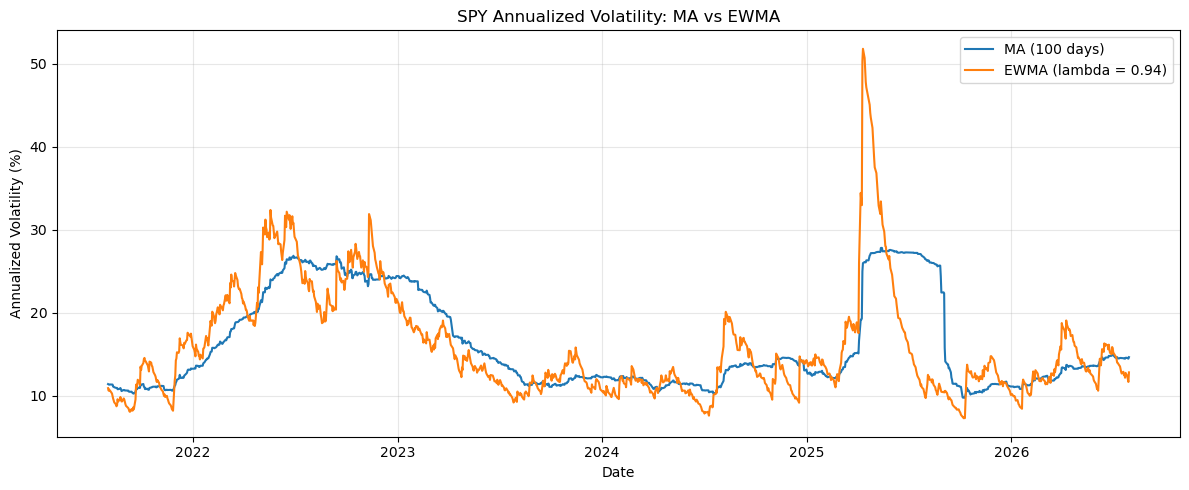

In [29]:
start_date = "2021-08-01"
end_date = "2026-07-30"

ma_plot = ma_vol.loc[start_date:end_date]
ewma_plot = ewma_vol.loc[start_date:end_date]

plt.figure(figsize=(12, 5))

plt.plot(
    ma_plot.index,
    ma_plot,
    label="MA (100 days)",
    linewidth=1.5
)

plt.plot(
    ewma_plot.index,
    ewma_plot,
    label="EWMA (lambda = 0.94)",
    linewidth=1.5
)

plt.title("SPY Annualized Volatility: MA vs EWMA")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Q1_MA_EWMA.png", dpi=300)
plt.show()

In [30]:
# Training period
train = returns.loc[
    "2025-06-01":"2026-05-31"
]

# Scale log returns to percentage units
train_pct = train * 100

# Fit GARCH(1,1)
model = arch_model(
    train_pct,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

result = model.fit(disp="off")

print(result.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.004
Vol Model:                      GARCH   Log-Likelihood:               -280.968
Distribution:                  Normal   AIC:                           567.937
Method:            Maximum Likelihood   BIC:                           578.501
                                        No. Observations:                  250
Date:                Sun, Sep 20 2026   Df Residuals:                      250
Time:                        22:47:30   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.0634  4.233e-02      1.497      0.134 [-1.95

In [31]:
# Extract fitted parameters
omega = result.params["omega"]
alpha1 = result.params["alpha[1]"]
beta1 = result.params["beta[1]"]

# Convert omega back to decimal-return units
alpha0 = omega / 10000

print("Estimated GARCH(1,1) parameters:")
print(f"alpha0 = {alpha0:.10f}")
print(f"alpha1 = {alpha1:.6f}")
print(f"beta1  = {beta1:.6f}")

if alpha1 + beta1 < 1:
    long_run_vol = np.sqrt(
        alpha0 / (1 - alpha1 - beta1)
    ) * np.sqrt(252) * 100

    print(
        f"Long-run annualized volatility: "
        f"{long_run_vol:.4f}%"
    )

print("Model convergence flag:", result.convergence_flag)

print(
    "alpha1 + beta1 =",
    alpha1 + beta1
)

print(
    "Number of training observations:",
    len(train)
)

Estimated GARCH(1,1) parameters:
alpha0 = 0.0000063387
alpha1 = 0.054889
beta1  = 0.834047
Long-run annualized volatility: 11.9926%
Model convergence flag: 0
alpha1 + beta1 = 0.88893599563387
Number of training observations: 250


In [32]:
# Forecast period: actual SPY trading dates
forecast_dates = returns.loc[
    "2026-06-01":"2026-07-30"
].index

M = 100
H = len(forecast_dates)

# Last in-sample conditional variance
last_variance = (
    result.conditional_volatility.iloc[-1] / 100
)**2

# Last observed in-sample log return
last_return = train.iloc[-1]

# Store simulated volatility paths
paths = np.zeros((H, M))

rng = np.random.default_rng(42)

for m in range(M):

    previous_variance = last_variance
    previous_return = last_return

    for h in range(H):

        # GARCH variance recursion
        variance = (
            alpha0
            + alpha1 * previous_return**2
            + beta1 * previous_variance
        )

        # Annualized volatility in percentage
        paths[h, m] = np.sqrt(variance * 252) * 100

        # Simulate next daily return
        z = rng.standard_normal()
        simulated_return = np.sqrt(variance) * z

        # Update state for next day
        previous_variance = variance
        previous_return = simulated_return

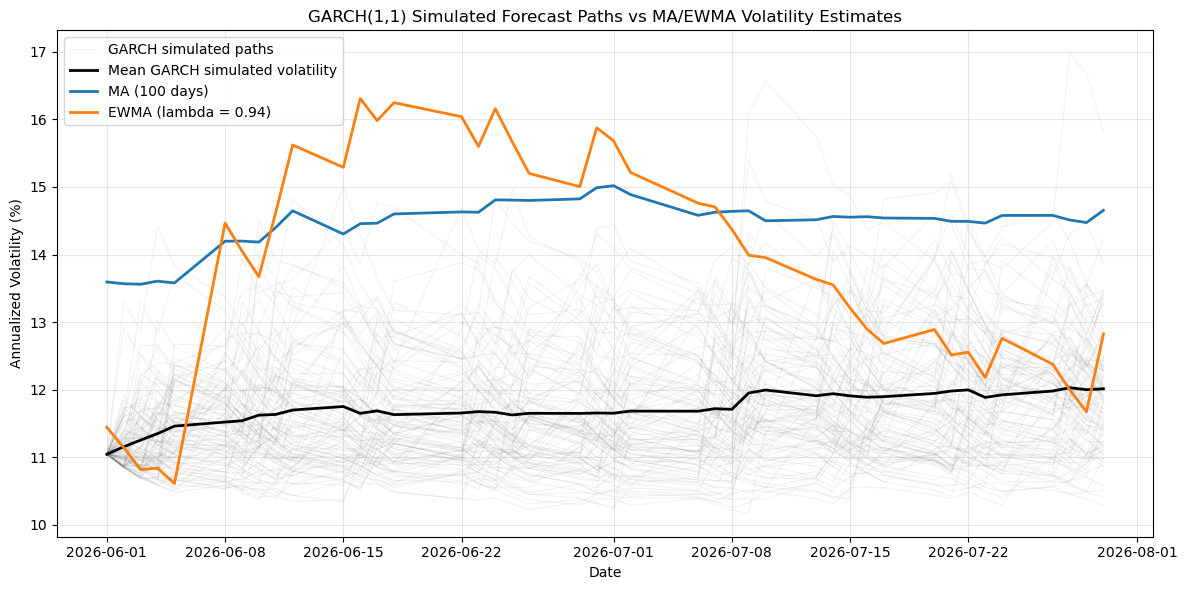

In [33]:
# MA and EWMA over the forecast period
ma_forecast = ma_vol.loc[
    "2026-06-01":"2026-07-30"
]

ewma_forecast = ewma_vol.loc[
    "2026-06-01":"2026-07-30"
]

plt.figure(figsize=(12, 6))

# Plot 100 GARCH sample paths
for m in range(M):
    plt.plot(
        forecast_dates,
        paths[:, m],
        color="gray",
        alpha=0.12,
        linewidth=0.7,
        label="GARCH simulated paths" if m == 0 else None
    )

# Mean simulated volatility
mean_path = paths.mean(axis=1)

plt.plot(
    forecast_dates,
    mean_path,
    color="black",
    linewidth=2,
    label="Mean GARCH simulated volatility"
)

# Historical MA and EWMA estimates
plt.plot(
    ma_forecast.index,
    ma_forecast,
    linewidth=2,
    label="MA (100 days)"
)

plt.plot(
    ewma_forecast.index,
    ewma_forecast,
    linewidth=2,
    label="EWMA (lambda = 0.94)"
)

plt.title(
    "GARCH(1,1) Simulated Forecast Paths "
    "vs MA/EWMA Volatility Estimates"
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Q3_GARCH_Forecast.png", dpi=300)
plt.show()

In [34]:

# Quantitative comparison
comparison = pd.DataFrame({
    "Mean GARCH Simulation": mean_path,
    "MA(100)": ma_forecast.to_numpy(),
    "EWMA(0.94)": ewma_forecast.to_numpy()
}, index=forecast_dates)

print("Average annualized volatility (%):")
print(comparison.mean().round(4))

print("\nVolatility at the end of forecast period (%):")
print(comparison.iloc[-1].round(4))

Average annualized volatility (%):
Mean GARCH Simulation    11.7213
MA(100)                  14.4578
EWMA(0.94)               13.8353
dtype: float64

Volatility at the end of forecast period (%):
Mean GARCH Simulation    12.0138
MA(100)                  14.6536
EWMA(0.94)               12.8231
Name: 2026-07-30 00:00:00, dtype: float64
